<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/alex/RA1_TP4/RA1_Trabajo_pr%C3%A1ctico_N%C2%B0_4_G8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TP4 - Aprendizaje no supervisado

#Ejercicio 1 - Triaje oncológico asistido por algoritmos


---
**Datasets:** `datos_pacientes.csv` y `datos_pacientes_diagnosticados.csv`

**Grupo:** Numero 8  
**Integrantes:** Acosta Alex, Bareiro Santiago, Borges Agustin  
**Fecha:** x/04/2026

>Un hospital regional de mediana complejidad atiende una cantidad creciente de pacientes derivados con
sospecha de tumor mamario. El cuello de botella no es la tecnología de diagnóstico (el hospital dispone
de equipamiento para biopsia digital) sino la disponibilidad del personal médico especializado: por
restricciones de recursos humanos, el equipo de oncología puede analizar y emitir diagnóstico definitivo
(benigno o maligno) para no más de 2 pacientes por día.
Actualmente hay 560 pacientes con estudios preliminares ya realizados en el sistema, esperando
diagnóstico. A ese ritmo, el último paciente de la lista esperaría 280 días. Para tumores malignos, esa
demora puede ser la diferencia entre un tratamiento efectivo y uno tardío.
El jefe del servicio de oncología propone implementar un sistema de triaje asistido por algoritmos: usar los
valores de los estudios preliminares disponibles para todos los pacientes (datos_pacientes.csv) para
identificar automáticamente cuáles tienen mayor probabilidad de tumor maligno y priorizarlos en la
agenda. Para calibrar y validar el sistema, el servicio dispone de un conjunto reducido de pacientes ya
diagnosticados por el equipo médico (datos_pacientes_diagnosticados.csv), con su resultado confirmado.
El dataset de estudios contiene 30 características computadas a partir de imágenes digitalizadas de
biopsias. El conjunto diagnosticado incluye, además, la columna diagnosis (M = maligno, B = benigno).
El jefe del servicio no rechazará el sistema si tiene un error ocasional. Lo rechazará si no puede entender
qué hace, si produce resultados inconsistentes o si no puede cuantificar el riesgo de que un paciente
maligno quede al final de la lista.





---


## 0. Configuración del entorno

In [2]:
# Dataset desde el repositorio en Drive

!wget -c --no-check-certificate "https://drive.google.com/uc?export=download&id=1CN6_hIjs4JFsJxnyijZmvAE0xcoyMONq&confirm=t" -O datos_pacientes.zip

--2026-04-22 17:52:16--  https://drive.google.com/uc?export=download&id=1CN6_hIjs4JFsJxnyijZmvAE0xcoyMONq&confirm=t
Resolving drive.google.com (drive.google.com)... 172.217.214.102, 172.217.214.100, 172.217.214.101, ...
Connecting to drive.google.com (drive.google.com)|172.217.214.102|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1CN6_hIjs4JFsJxnyijZmvAE0xcoyMONq&export=download [following]
--2026-04-22 17:52:16--  https://drive.usercontent.google.com/download?id=1CN6_hIjs4JFsJxnyijZmvAE0xcoyMONq&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 173.194.194.132, 2607:f8b0:4001:c10::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|173.194.194.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50200 (49K) [application/octet-stream]
Saving to: ‘datos_pacientes.zip’

datos_pacientes.zip 100%[===================>]

In [3]:
!unzip datos_pacientes.zip

Archive:  datos_pacientes.zip
  inflating: datos_pacientes_diagnosticados.csv  
  inflating: datos_pacientes.csv     


In [12]:
# @title *Esta celda importa utilidades comunes al colab*
# @title Importaciones
import sys, os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    silhouette_samples
)
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.pipeline import Pipeline

try:
    import umap
except ImportError:
    !pip install umap-learn -q
    import umap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
print("Entorno listo.")


Entorno listo.


### 0.1 EDA

In [14]:
df_pacientes = pd.read_csv('datos_pacientes.csv')
df_pacientes_diagnosticados = pd.read_csv('datos_pacientes_diagnosticados.csv')

Se muestran los primeros 5 pacientes del dataset_pacientes y revisamos el dataset_pacientes_diagnosticados por completo

In [18]:
print("=== dataset_pacientes ===")
print(f"Dimensión: {df_pacientes.shape}  ({df_pacientes.shape[0]} pacientes, {df_pacientes.shape[1]} columnas)")
print(f"Columnas: {list(df_pacientes.columns)}")
df_pacientes.head()

=== dataset_pacientes ===
Dimensión: (560, 31)  (560 pacientes, 31 columnas)
Columnas: ['id', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,915940,14.580,13.66,94.29,658.8,0.09832,0.08918,0.08222,0.043490,0.1739,...,16.76,17.24,108.50,862.0,0.1223,0.1928,0.24920,0.09186,0.2626,0.07048
1,893988,11.540,10.72,73.73,409.1,0.08597,0.05969,0.01367,0.008907,0.1833,...,12.34,12.87,81.23,467.8,0.1092,0.1626,0.08324,0.04715,0.3390,0.07434
2,8910251,10.600,18.95,69.28,346.4,0.09688,0.11470,0.06387,0.026420,0.1922,...,11.88,22.94,78.28,424.8,0.1213,0.2515,0.19160,0.07926,0.2940,0.07587
3,8510824,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,10.23,15.66,65.13,314.9,0.1324,0.1148,0.08867,0.06227,0.2450,0.07773
4,90944601,13.780,15.79,88.37,585.9,0.08817,0.06718,0.01055,0.009937,0.1405,...,15.27,17.50,97.90,706.6,0.1072,0.1071,0.03517,0.03312,0.1859,0.06810


In [20]:
print("=== dataset_pacientes_diagnosticados ===")
print(f"Dimensión: {df_pacientes_diagnosticados.shape}  ({df_pacientes_diagnosticados.shape[0]} pacientes, {df_pacientes_diagnosticados.shape[1]} columnas)")
print(f"Distribución de diagnóstico:\n{df_pacientes_diagnosticados['diagnosis'].value_counts()}")
df_pacientes_diagnosticados.head()

=== dataset_pacientes_diagnosticados ===
Dimensión: (9, 32)  (9 pacientes, 32 columnas)
Distribución de diagnóstico:
diagnosis
B    6
M    3
Name: count, dtype: int64


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,898677,B,10.26,14.71,66.20,321.6,0.09882,0.09159,0.035810,0.020370,...,10.88,19.48,70.89,357.1,0.1360,0.1636,0.07162,0.04074,0.2434,0.08488
1,913505,M,19.44,18.82,128.10,1167.0,0.10890,0.14480,0.225600,0.119400,...,23.96,30.39,153.90,1740.0,0.1514,0.3725,0.59360,0.20600,0.3266,0.09009
2,912519,B,13.47,14.06,87.32,546.3,0.10710,0.11550,0.057860,0.052660,...,14.83,18.32,94.94,660.2,0.1393,0.2499,0.18480,0.13350,0.3227,0.09326
3,84667401,M,13.73,22.61,93.60,578.3,0.11310,0.22930,0.212800,0.080250,...,15.03,32.01,108.80,697.7,0.1651,0.7725,0.69430,0.22080,0.3596,0.14310
4,874158,B,10.08,15.11,63.76,317.5,0.09267,0.04695,0.001597,0.002404,...,11.87,21.18,75.39,437.0,0.1521,0.1019,0.00692,0.01042,0.2933,0.07697


Vamos a revisar si hay valores nulos en ambas datasets

In [21]:
# Verificación de nulos
print("Nulos en datos_pacientes:")
print(df_pacientes.isnull().sum().sum(), "valores nulos totales")
print("\nNulos en datos_pacientes_diagnosticados:")
print(df_pacientes_diagnosticados.isnull().sum().sum(), "valores nulos totales")

Nulos en datos_pacientes:
0 valores nulos totales

Nulos en datos_pacientes_diagnosticados:
0 valores nulos totales


In [25]:
# Estadísticas descriptivas de los 560 pacientes
df_pacientes.describe().T.style.background_gradient(cmap="Blues", subset=["mean", "std", "min", "max"])

,count,mean,std,min,25%,50%,75%,max
id,560.000000,30536072.607143,125933045.657819,8670.000000,869222.500000,906157.000000,8825022.250000,911320502.000000
radius_mean,560.000000,14.139805,3.524507,6.981000,11.707500,13.355000,15.797500,28.110000
texture_mean,560.000000,19.343804,4.288002,9.710000,16.292500,18.890000,21.812500,39.280000
perimeter_mean,560.000000,92.048107,24.307755,43.790000,75.200000,86.210000,104.150000,188.500000
area_mean,560.000000,656.062500,352.594258,143.500000,420.300000,551.400000,784.150000,2501.000000
smoothness_mean,560.000000,0.096239,0.014122,0.052630,0.085992,0.095720,0.105150,0.163400
compactness_mean,560.000000,0.104211,0.052825,0.019380,0.064815,0.092525,0.130425,0.345400
concavity_mean,560.000000,0.088747,0.079782,0.000000,0.029540,0.061400,0.131000,0.426800
concave points_mean,560.000000,0.048890,0.038822,0.000000,0.020310,0.033455,0.073730,0.201200
symmetry_mean,560.000000,0.181178,0.027575,0.106000,0.161875,0.179250,0.195700,0.304000


### 0.2 Distribución de las features

Visualizamos la distribución de las 30 features para detectar asimetrías, outliers y escalas muy distintas (justificación para aplicar `StandardScaler`).

Total de features: 30


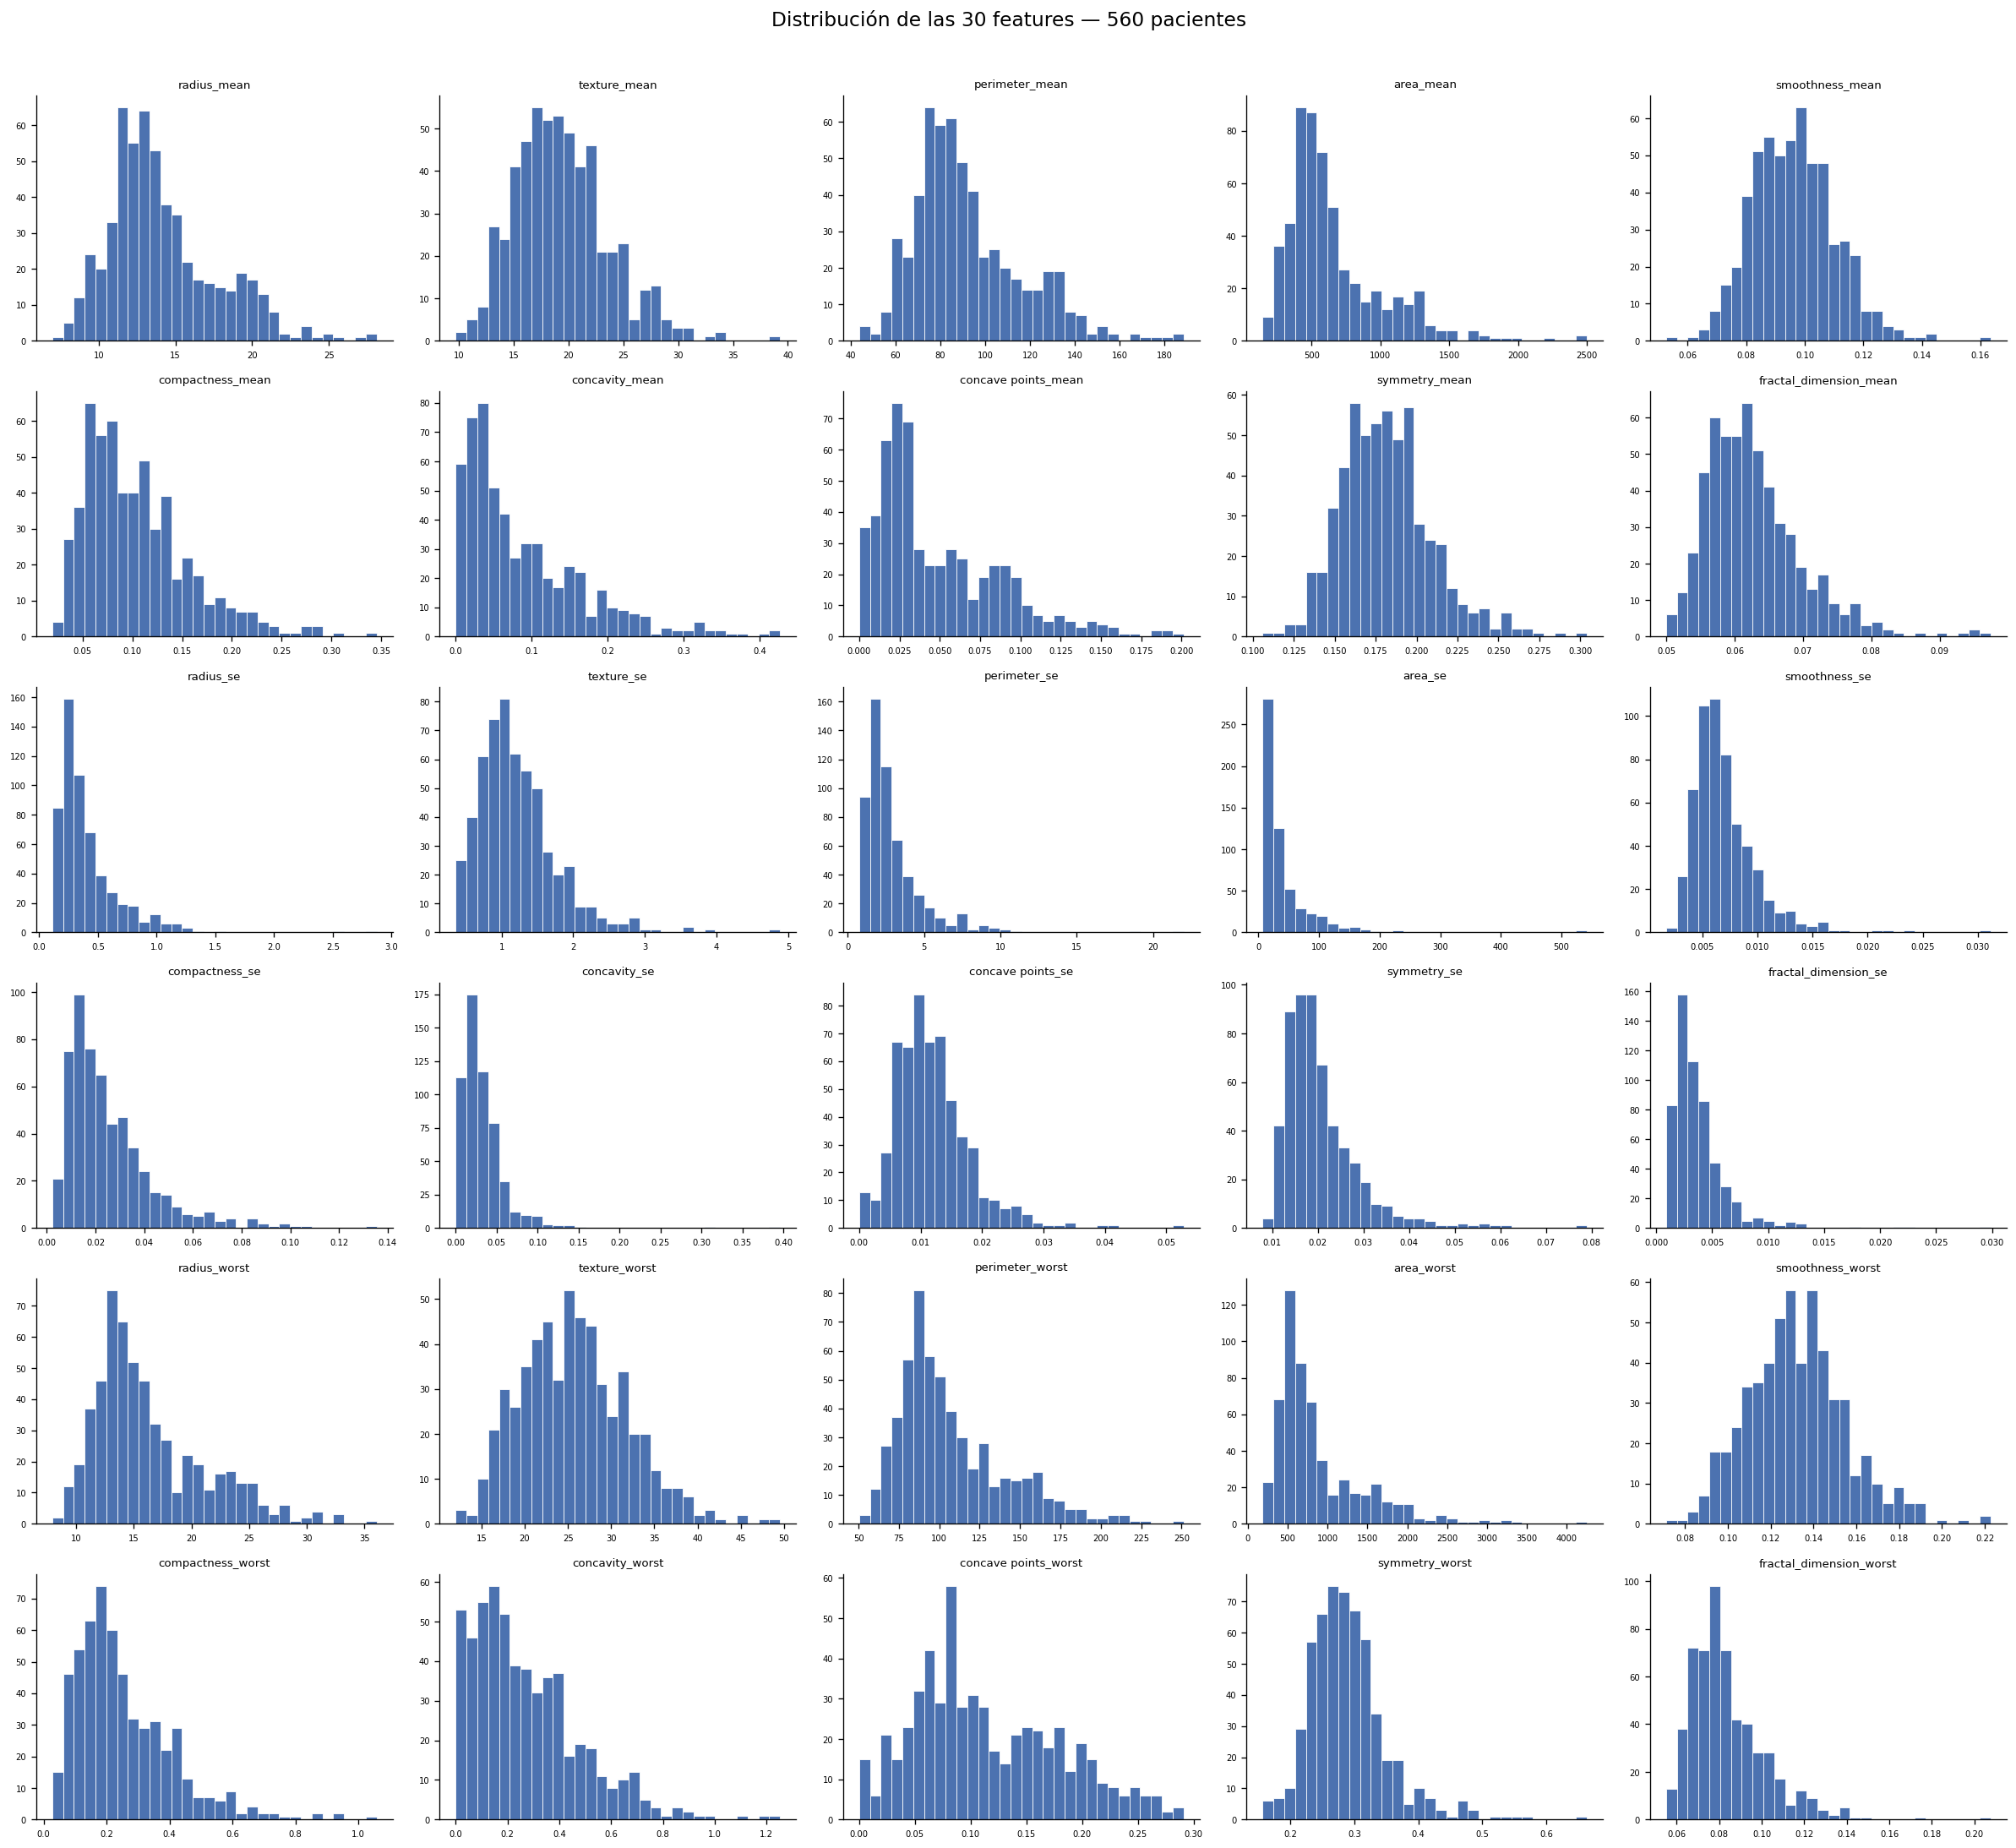

In [26]:
# Identificar columnas de features (excluir id)
feature_cols = [c for c in df_pacientes.columns if c != "id"]
print(f"Total de features: {len(feature_cols)}")

fig, axes = plt.subplots(6, 5, figsize=(20, 18))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    axes[i].hist(df_pacientes[col], bins=30, color="#4C72B0", edgecolor="white", linewidth=0.5)
    axes[i].set_title(col, fontsize=8)
    axes[i].tick_params(labelsize=6)
plt.suptitle("Distribución de las 30 features — 560 pacientes", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

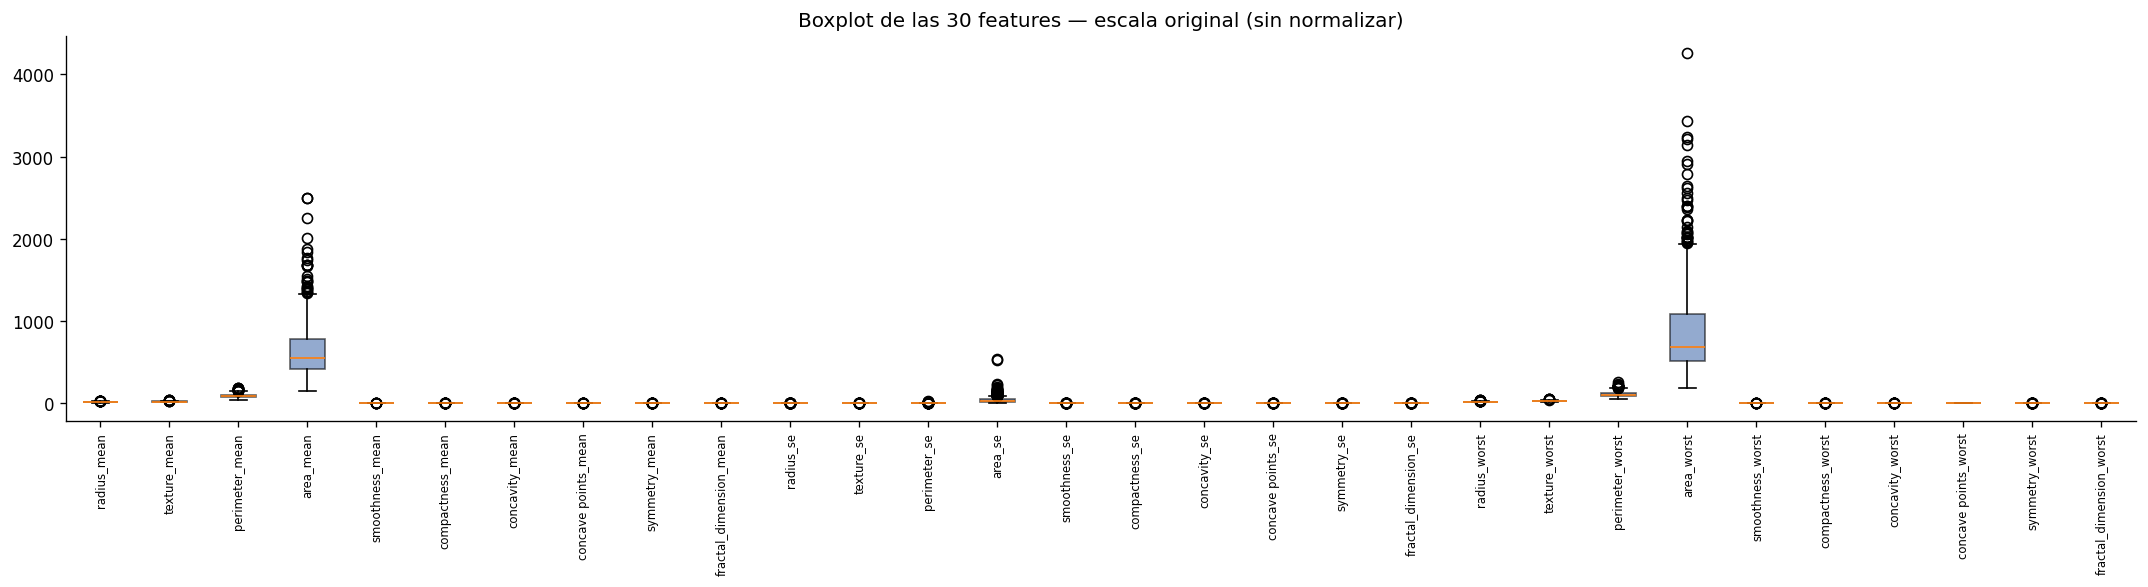

In [28]:
# Boxplot para visualizar rango y outliers por feature
X_raw = df_pacientes[feature_cols].values
fig, ax = plt.subplots(figsize=(18, 5))
ax.boxplot(X_raw, labels=feature_cols, vert=True, patch_artist=True,
           boxprops=dict(facecolor="#4C72B0", alpha=0.6))
ax.set_xticklabels(feature_cols, rotation=90, fontsize=7)
ax.set_title("Boxplot de las 30 features — escala original (sin normalizar)")
plt.tight_layout()
plt.show()

Observación: features como area_mean tienen rango de ~1000 mientras que smoothness_mean tiene rango ~0.1. Sin escalar, K-Means basado en distancias euclidianas estaría dominado por las features de mayor magnitud.



---


##1. Construcción y ensamblado del pipeline



---


##2. Entrenamiento y comparación de modelos



---


## 3. Optimización

### 3.1 Selección del Modelo y Búsqueda de Hiperparámetros



### 3.2 Análisis de Métricas y Comparación de Modelos

### 3.3 Identificación del modelo con la mejor métrica:

### 3.5 Entrenamiento del mejor modelo con mas y menos features



### 3.6 Grafica de los residuos del mejor modelo



---


## 4. Conclusiones

